In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from datasets import load_dataset

Load the dair-ai/emotion dataset from Hugging Face.https://huggingface.co/datasets/dair-ai/emotion

The dataset contains `train`, `validation`, and `test` splits. Each split has `text` (the emotional content) and `label` (the corresponding emotion). The emotions are mapped to numerical labels, and their names can be retrieved from `emotion_dataset['train'].features['label'].names`.

In [2]:
emotion_dataset=load_dataset('dair-ai/emotion')
train_text     =emotion_dataset['train']['text']
train_label    =emotion_dataset['train']['label']

test_text      =emotion_dataset['test']['text']
test_label     =emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names
print(f"Label names: {label_names}")

Label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [4]:
num_labels = len(label_names)
print(f"Number of labels: {num_labels}")

Number of labels: 6


In [5]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_test = pd.DataFrame({'text': test_text, 'label': [label_names[i] for i in test_label]})

print("df_train and df_test DataFrames created successfully.")

df_train and df_test DataFrames created successfully.


In [6]:
display(df_train.head())

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [7]:
display(df_test.head())

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


<Axes: xlabel='label', ylabel='count'>

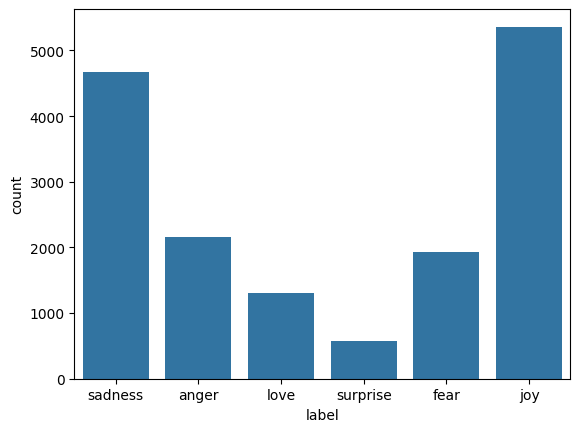

In [8]:
sns.countplot(x='label', data=df_train)


In [9]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from sklearn.preprocessing import LabelEncoder

max_words = 10000
max_len = 100
tokenizer = Tokenizer(num_words=max_words,oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequences = tokenizer.texts_to_sequences(df_train['text'])
test_sequences = tokenizer.texts_to_sequences(df_test['text'])
padded_test_sequences = pad_sequences(test_sequences, maxlen=max_len)
padded_train_sequences = pad_sequences(train_sequences, maxlen=max_len)

train_labels = np.array(df_train['label'])
test_labels = np.array(df_test['label'])

# Encode labels numerically for train_test_split stratification
label_encoder = LabelEncoder()
train_labels_encoded = label_encoder.fit_transform(train_labels)
test_labels_encoded = label_encoder.transform(test_labels)

num_classes = len(label_encoder.classes_)

print(f"Vocabulary size: {len(tokenizer.word_index) }")
print(f"max senetence length: {max_len}")
print(f"Number of classes: {num_classes}")

Vocabulary size: 15213
max senetence length: 100
Number of classes: 6


In [10]:
from sklearn.utils import class_weight

class_weights    = class_weight.compute_class_weight(
    class_weight ='balanced',
    classes      = np.unique(train_labels_encoded),
    y            = train_labels_encoded
)
class_weights_dict = dict(enumerate(class_weights))

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor = 'val_loss',
    patience = 3,
    verbose = 1,
    restore_best_weights = True
)

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN, Dense, Dropout, LSTM,GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(units=128,return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
rnn_model.fit(
    padded_train_sequences,
    train_labels_encoded,
    validation_data=(padded_test_sequences, test_labels_encoded),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequences, test_labels_encoded)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 46s 84ms/step - accuracy: 0.1624 - loss: 2.0570 - val_accuracy: 0.1120 - val_loss: 1.8916
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.1512 - loss: 1.8856 - val_accuracy: 0.0795 - val_loss: 1.8075
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.1348 - loss: 1.8246 - val_accuracy: 0.0330 - val_loss: 1.8261
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 81s 83ms/step - accuracy: 0.1218 - loss: 1.8064 - val_accuracy: 0.2905 - val_loss: 1.7570
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.1411 - loss: 1.8014 - val_accuracy: 0.0330 - val_loss: 1.8295
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.1334 - loss: 1.8025 - val_accuracy: 0.3475 - val_loss: 1.7282
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.1401 - loss: 1.8009 - val_accuracy: 0.1375 - val_loss: 1.8034
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 83ms/step - accuracy: 0.1433 - loss: 1.8009 - 

In [14]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequences,
    train_labels_encoded,
    validation_data=(padded_test_sequences, test_labels_encoded),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequences, test_labels_encoded)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 124s 240ms/step - accuracy: 0.4121 - loss: 1.3939 - val_accuracy: 0.8165 - val_loss: 0.6942
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 240ms/step - accuracy: 0.8903 - loss: 0.3468 - val_accuracy: 0.9075 - val_loss: 0.2854
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 118s 237ms/step - accuracy: 0.9344 - loss: 0.2025 - val_accuracy: 0.9065 - val_loss: 0.2587
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 143s 239ms/step - accuracy: 0.9503 - loss: 0.1428 - val_accuracy: 0.9045 - val_loss: 0.2616
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 120s 240ms/step - accuracy: 0.9654 - loss: 0.1038 - val_accuracy: 0.9165 - val_loss: 0.2598
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 122s 243ms/step - accuracy: 0.9628 - loss: 0.1126 - val_accuracy: 0.9110 - val_loss: 0.3105
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.9065 - loss: 0.2587
LSTM Loss: 0.2586853504180908
LSTM Accuracy: 0.9064

In [15]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([
    Embedding(input_dim=max_words, output_dim=128),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

gru_model.fit(
    padded_train_sequences,
    train_labels_encoded,
    validation_data=(padded_test_sequences, test_labels_encoded),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequences, test_labels_encoded)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 107s 204ms/step - accuracy: 0.4763 - loss: 1.2286 - val_accuracy: 0.8960 - val_loss: 0.3547
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 104s 207ms/step - accuracy: 0.9237 - loss: 0.2241 - val_accuracy: 0.9120 - val_loss: 0.2819
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 212ms/step - accuracy: 0.9489 - loss: 0.1359 - val_accuracy: 0.9245 - val_loss: 0.1812
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 103s 207ms/step - accuracy: 0.9604 - loss: 0.1050 - val_accuracy: 0.9200 - val_loss: 0.2254
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 141s 204ms/step - accuracy: 0.9639 - loss: 0.0910 - val_accuracy: 0.9230 - val_loss: 0.2199
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 209ms/step - accuracy: 0.9721 - loss: 0.0767 - val_accuracy: 0.9170 - val_loss: 0.2926
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9245 - loss: 0.1812
GRU Loss: 0.18120774626731873
GRU Accuracy: 0.92449

In [16]:
results = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Loss': [rnn_loss, lstm_loss, gru_loss],
    'Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Accuracy', ascending=False)

results

,Model,Loss,Accuracy
2,GRU,0.181208,0.9245
1,LSTM,0.258685,0.9065
0,RNN,1.728235,0.3475


In [17]:
from tensorflow.keras.layers import Bidirectional, GRU, Embedding, Dropout, Dense
from tensorflow.keras.models import Sequential

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.layers import Bidirectional, GRU, Embedding, Dropout, Dense
from tensorflow.keras.models import Sequential

BiGRU = Sequential([
    Embedding(input_dim=max_words, output_dim=300),
    Bidirectional(GRU(units=128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(units=64)),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax')
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
BiGRU.fit(
    padded_train_sequences,
    train_labels_encoded,
    validation_data=(padded_test_sequences, test_labels_encoded),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels_encoded)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 299s 586ms/step - accuracy: 0.5624 - loss: 1.0644 - val_accuracy: 0.9060 - val_loss: 0.2991
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 321s 583ms/step - accuracy: 0.9313 - loss: 0.1962 - val_accuracy: 0.9240 - val_loss: 0.1952
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 304s 608ms/step - accuracy: 0.9517 - loss: 0.1279 - val_accuracy: 0.9170 - val_loss: 0.2357
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.9060 - loss: 0.2991
BiGRU Loss: 0.2990877628326416
BiGRU Accuracy: 0.906000018119812


In [20]:
BiGRU.fit(
    padded_train_sequences,
    train_labels_encoded,
    validation_data=(padded_test_sequences, test_labels_encoded),
    epochs=20,
    batch_size=32,
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequences, test_labels_encoded)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 292s 583ms/step - accuracy: 0.9257 - loss: 0.2077 - val_accuracy: 0.9190 - val_loss: 0.2436
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 296s 592ms/step - accuracy: 0.9501 - loss: 0.1333 - val_accuracy: 0.9215 - val_loss: 0.2152
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 294s 588ms/step - accuracy: 0.9638 - loss: 0.0967 - val_accuracy: 0.9210 - val_loss: 0.2880
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.9190 - loss: 0.2436
BiGRU Loss: 0.24363932013511658
BiGRU Accuracy: 0.9190000295639038


63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step


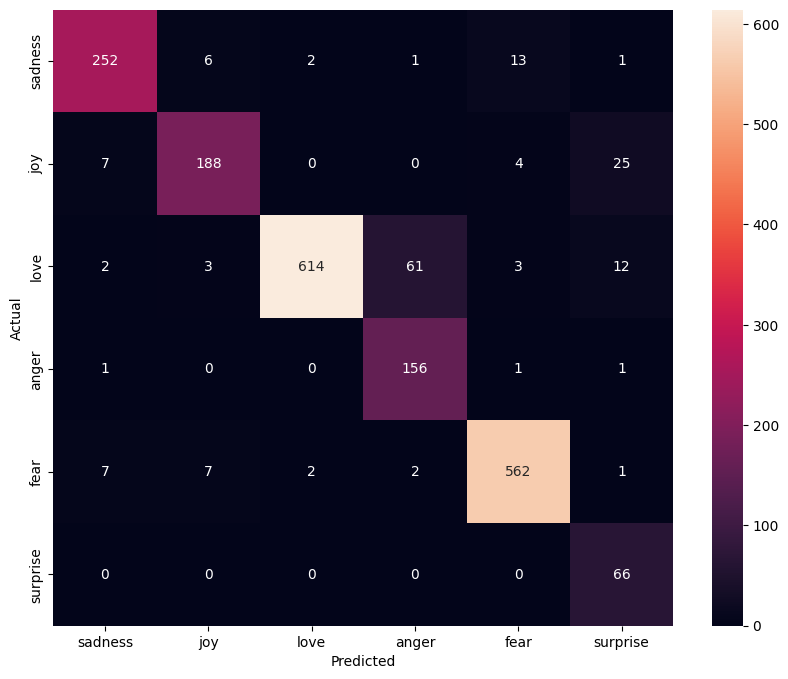

In [21]:
from sklearn.metrics import confusion_matrix
BiGRU_predictions = BiGRU.predict(padded_test_sequences)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(test_labels_encoded, BiGRU_predictions.argmax(axis=1)),
            annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [22]:
sample_texts = [
    "I can't belive how happy i an right now,this is amzing",
    "I feel so alone and hopless today",
    "I am terrified when walking down dark alleyways alon.",
    "I was shocked and completely superised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=max_len, padding='post', truncating='post')

# Get predictions and convert back to labels
predictions_logits = BiGRU.predict(sample_padded_sequences)
sample_prediction_indices = np.argmax(predictions_logits, axis=1)

for i in range(len(sample_texts)):
    emotion = label_names[sample_prediction_indices[i]]
    print(f'Text: {sample_texts[i]}')
    print(f'Predicted Emotion: {emotion}\n')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Text: I can't belive how happy i an right now,this is amzing
Predicted Emotion: sadness

Text: I feel so alone and hopless today
Predicted Emotion: fear

Text: I am terrified when walking down dark alleyways alon.
Predicted Emotion: joy

Text: I was shocked and completely superised by the unexpected gift!
Predicted Emotion: surprise



In [23]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)

BiGRU.save(os.path.join(model_dir, 'BiGRU_modle.keras'))

with open(os.path.join(model_dir, 'tokenizer.pickle'), 'wb') as file:
    pickle.dump(tokenizer,file)

